### Standard-deviation plot: multi-entropy ratio, $V=17$, $\beta=0.05$

Single-line plot of $[S_2^{(3)}]_{\text{ED}} / [S_2^{(3)}]_{\text{analytical}}$ vs. $g$,
with error bars from the numerical standard deviation (old partition, no suffix).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
V = 17
beta = 0.05
color = "tab:blue"

# ── Font sizes ─────────────
LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 18

# ── Marker / error-bar sizing ──────────────────────────
MARKERSIZE = 6
LINEWIDTH  = 1.8
ELINEWIDTH = 2.0
CAPSIZE    = 4
CAPTHICK   = 2.0

In [4]:
BASE_DIR = Path(".")

file_name_multi_numerical = (
    BASE_DIR / "data" / "multi_numerical"
    / f"L_{V}_multi_entropy_k_500_beta_{beta:.2f}.csv"
)
file_name_multi_analytical = (
    BASE_DIR / "data" / "multi_analytical"
    / f"L_{V}_multi_analytical_beta_{beta:.2f}.csv"
)

# read data
data_multi_numerical = pd.read_csv(file_name_multi_numerical, header=None)
data_multi_analytical = pd.read_csv(file_name_multi_analytical, header=None)

# compute ratio and standard deviation
g_list = data_multi_numerical[0]
multi_entropy_ratio = data_multi_numerical[1] / data_multi_analytical[1]
multi_entropy_ratio_std = np.sqrt(data_multi_numerical[2]) / data_multi_analytical[1]

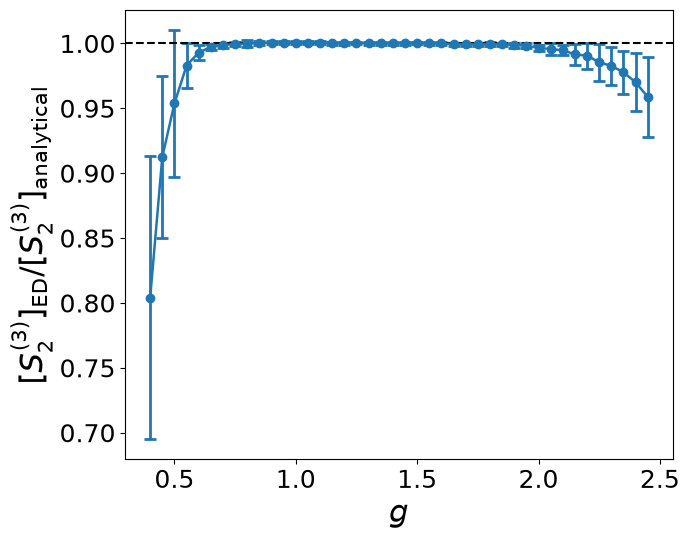

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.errorbar(
    g_list,
    multi_entropy_ratio,
    yerr=multi_entropy_ratio_std,
    color=color,
    marker="o",
    markersize=MARKERSIZE,
    linewidth=LINEWIDTH,
    elinewidth=ELINEWIDTH,
    capsize=CAPSIZE,
    capthick=CAPTHICK,
)

ax.axhline(y=1, color="black", linestyle="--")

ax.set_xlabel(r"$g$", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(
    r"$[S_2^{(3)}]_{\text{ED}} / [S_2^{(3)}]_{\text{analytical}}$",
    fontsize=LABEL_FONTSIZE,
)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

fig.tight_layout()
fig.savefig(
    BASE_DIR / f"fig_6.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()